# Three-Stage Multimodal Model — MHC Class II (NEW OPTIM system)




In [1]:
import os
import copy
from contextlib import nullcontext
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt

DATA_PATH = "/Users/shubhaychoubey/Documents/GitHub/Peptides/Data/ML_Ready/mhc_class_II.csv"
CACHE_DIR = "/Users/shubhaychoubey/Documents/GitHub/Peptides/Methods/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_PEP_LEN = 25
N_TOP_BIO = 8
RANDOM_STATE = 42

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Device:", device)

Device: mps


## 1. Data uniqueness audit


In [2]:
raw = pd.read_csv(DATA_PATH, low_memory=False)

audit = {
    "rows": len(raw),
    "unique_peptides": raw["Peptide Sequence"].nunique(),
    "unique_pep_allele_pairs": raw.groupby(["Peptide Sequence", "Best HLA Allele"]).ngroups,
    "unique_alleles": raw["Best HLA Allele"].nunique(),
}
audit["duplicate_pep_allele_rows"] = audit["rows"] - audit["unique_pep_allele_pairs"]
for k, v in audit.items():
    print(f"{k:26s}: {v:,}")

label_conflict = raw.groupby("Peptide Sequence")["is_cancer"].nunique()
conflict_peptides = label_conflict[label_conflict > 1].index
print(f"\npeptides with conflicting labels: {len(conflict_peptides):,}")

rows                      : 10,975
unique_peptides           : 9,611
unique_pep_allele_pairs   : 9,867
unique_alleles            : 54
duplicate_pep_allele_rows : 1,108

peptides with conflicting labels: 160


In [3]:
df = raw.dropna(subset=["is_cancer", "Peptide Sequence", "Best HLA Allele"]).copy()
df["is_cancer"] = df["is_cancer"].astype(int)
df = df[~df["Peptide Sequence"].isin(conflict_peptides)]
df = df.drop_duplicates(subset=["Peptide Sequence", "Best HLA Allele"]).reset_index(drop=True)

print(f"rows after removing conflicts and duplicate pairs: {len(df):,}")
print(df["is_cancer"].value_counts().rename({0: "healthy", 1: "cancer"}).to_string())

rows after removing conflicts and duplicate pairs: 9,633
is_cancer
cancer     4837
healthy    4796


In [ ]:
print(df.head())

## 2. Class II HLA groove library and allele uniqueness



In [4]:
classII_groove_library = {
    "HLA-DPB1*04:01": "XXXDHVSTYAAFVQTHRPTGEFMFEFDEDEMFYVDLDKKETVWHLEEFGQAFSFEAQGGLANIAILNNNLNTLIQRSNHTNYLFQGRQECYAFNGTQRFLERYIYNREEFARFDSDVGEFRAVTELGRPAAEYWNSQKDILEEKRAVPDRMCRHNYELGGPMTLQ",
    "HLA-DPB1*11:01": "XXXDHVSTYAAFVQTHRPTGEFMFEFDEDEMFYVDLDKKETVWHLEEFGQAFSFEAQGGLANIAILNNNLNTLIQRSNHTNYVYQLRQECYAFNGTQRFLERYIYNRQEYARFDSDVGEFRAVTELGRPAAEYWNSQKDLLEERRAVPDRMCRHNYELDEAVTLQ",
    "HLA-DQA1*01:01/DQB1*03:01": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEEFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKAMCYFTNGTERVRYVTRYIYNREEYARFDSDVEVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*01:01/DQB1*05:01": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEEFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGLCYFTNGTERVRGVTRHIYNREEYVRFDSDVGVYRAVTPQGRPVAEYWNSQKEVLEGARASVDRVCRHNYEVAYRGI",
    "HLA-DQA1*01:02/DQB1*03:02": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEQFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGMCYFTNGTERVRLVTRYIYNREEYARFDSDVGVYRAVTPLGPPAAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*01:02/DQB1*03:03": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEQFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGMCYFTNGTERVRLVTRYIYNREEYARFDSDVGVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*01:02/DQB1*05:01": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEQFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGLCYFTNGTERVRGVTRHIYNREEYVRFDSDVGVYRAVTPQGRPVAEYWNSQKEVLEGARASVDRVCRHNYEVAYRGI",
    "HLA-DQA1*01:02/DQB1*06:02": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEQFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVFQFKGMCYFTNGTERVRLVTRYIYNREEYARFDSDVGVYRAVTPQGRPDAEYWNSQKEVLEGTRAELDTVCRHNYEVAFRGI",
    "HLA-DQA1*01:02/DQB1*06:04": "VADHVASCGVNLYQFYGPSGQYTHEFDGDEQFYVDLERKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGMCYFTNGTERVRLVTRHIYNREEYARFDSDVGVYRAVTPQGRPVAEYWNSQKEVLERTRAELDTVCRHNYEVGYRGI",
    "HLA-DQA1*01:03/DQB1*06:03": "XXDHVASCGVNLYQFYGPSGQFTHEFDGDEQFYVDLEKKETAWRWPEFSKFGGFDPQGALRNMAVAKHNLNIMIKRYNSTDFVYQFKGMCYFTNGTERVRLVTRHIYNREEYARFDSDVGVYRAVTPQGRPDAEYWNSQKEVLEGTRAELDTVCRHNYEVAFRGI",
    "HLA-DQA1*02:01/DQB1*02:02": "XXDHVASYGVNLYQSYGPSGQFTHEFDGDEEFYVDLERKETVWKLPLFHRLRFDPQFALTNIAVLKHNLNILIKRSNSTADFVYQFKGMCYFTNGTERVRLVSRSIYNREEIVRFDSDVGEFRAVTLLGLPAAEYWNSQKDILERKRAAVDRVCRHNYQLELRTT",
    "HLA-DQA1*02:01/DQB1*03:01": "XXDHVASYGVNLYQSYGPSGQFTHEFDGDEEFYVDLERKETVWKLPLFHRLRFDPQFALTNIAVLKHNLNILIKRSNSTADFVYQFKAMCYFTNGTERVRYVTRYIYNREEYARFDSDVEVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*02:01/DQB1*03:03": "XXDHVASYGVNLYQSYGPSGQFTHEFDGDEEFYVDLERKETVWKLPLFHRLRFDPQFALTNIAVLKHNLNILIKRSNSTADFVYQFKGMCYFTNGTERVRLVTRYIYNREEYARFDSDVGVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*02:01/DQB1*06:03": "XXDHVASYGVNLYQSYGPSGQFTHEFDGDEEFYVDLERKETVWKLPLFHRLRFDPQFALTNIAVLKHNLNILIKRSNSTADFVYQFKGMCYFTNGTERVRLVTRHIYNREEYARFDSDVGVYRAVTPQGRPDAEYWNSQKEVLEGTRAELDTVCRHNYEVAFRGI",
    "HLA-DQA1*03:01/DQB1*02:01": "VADHVASYGVNLYQSYGPSGQYSHEFDGDEEFYVDLERKETVWQLPLFRRFRRFDPQFALTNIAVLKHNLNIVIKRSNSTDFVYQFKGMCYFTNGTERVRLVSRSIYNREEIVRFDSDVGEFRAVTLLGLPAAEYWNSQKDILERKRAAVDRVCRHNYQLELRTT",
    "HLA-DQA1*03:01/DQB1*03:01": "VADHVASYGVNLYQSYGPSGQYSHEFDGDEEFYVDLERKETVWQLPLFRRFRRFDPQFALTNIAVLKHNLNIVIKRSNSTDFVYQFKAMCYFTNGTERVRYVTRYIYNREEYARFDSDVEVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*03:01/DQB1*03:02": "VADHVASYGVNLYQSYGPSGQYSHEFDGDEEFYVDLERKETVWQLPLFRRFRRFDPQFALTNIAVLKHNLNIVIKRSNSTDFVYQFKGMCYFTNGTERVRLVTRYIYNREEYARFDSDVGVYRAVTPLGPPAAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*05:01/DQB1*02:01": "VADHVASYGVNLYQSYGPSGQYTHEFDGDEQFYVDLGRKETVWCLPVLRQFRFDPQFALTNIAVLKHNLNSLIKRSNSTADFVYQFKGMCYFTNGTERVRLVSRSIYNREEIVRFDSDVGEFRAVTLLGLPAAEYWNSQKDILERKRAAVDRVCRHNYQLELRTT",
    "HLA-DQA1*05:01/DQB1*03:01": "VADHVASYGVNLYQSYGPSGQYTHEFDGDEQFYVDLGRKETVWCLPVLRQFRFDPQFALTNIAVLKHNLNSLIKRSNSTADFVYQFKAMCYFTNGTERVRYVTRYIYNREEYARFDSDVEVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*05:05/DQB1*03:01": "VADHVASYGVNLYQSYGPSGQYTHEFDGDEQFYVDLGRKETVWCLPVLRQFRFDPQFALTNIAVLKHNLNSLIKRSNSTADFVYQFKAMCYFTNGTERVRYVTRYIYNREEYARFDSDVEVYRAVTPLGPPDAEYWNSQKEVLERTRAELDTVCRHNYQLELRTT",
    "HLA-DQA1*05:05/DQB1*04:02": "VADHVASYGVNLYQSYGPSGQYTHEFDGDEQFYVDLGRKETVWCLPVLRQFRFDPQFALTNIAVLKHNLNSLIKRSNSTADFVFQFKGMCYFTNGTERVRGVTRYIYNREEYARFDSDVGVYRAVTPLGRLDAEYWNSQKDILEEDRASVDTVCRHNYQLELRTT",
    "HLA-DQA1*05:05/DQB1*05:01": "VADHVASYGVNLYQSYGPSGQYTHEFDGDEQFYVDLGRKETVWCLPVLRQFRFDPQFALTNIAVLKHNLNSLIKRSNSTADFVYQFKGLCYFTNGTERVRGVTRHIYNREEYVRFDSDVGVYRAVTPQGRPVAEYWNSQKEVLEGARASVDRVCRHNYEVAYRGI",
    "HLA-DRB1*01:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQLKFECHFFNGTERVRLLERCIYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*01:02": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQLKFECHFFNGTERVRLLERCIYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAAVDTYCRHNYGAVXXXX",
    "HLA-DRB1*01:03": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQLKFECHFFNGTERVRLLERCIYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDILEDERAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*03:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRYLDRYFHNQEENVRFDSDVGEFRAVTELGRPDAEYWNSQKDLLEQKRGRVDNYCRHNYGVVESFT",
    "HLA-DRB1*04:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQVKHECHFFNGTERVRFLDRYFYHQEEYVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQKRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*04:04": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQVKHECHFFNGTERVRFLDRYFYHQEEYVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAAVDTYCRHNYGVVESFT",
    "HLA-DRB1*04:05": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQVKHECHFFNGTERVRFLDRYFYHQEEYVRFDSDVGEYRAVTELGRPSAEYWNSQKDLLEQRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*04:07": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQVKHECHFFNGTERVRFLDRYFYHQEEYVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAEVDTYCRHNYGVGESFT",
    "HLA-DRB1*07:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQGKYKCHFFNGTERVQFLERLFYNQEEFVRFDSDVGEYRAVTELGRPVAESWNSQKDILEDRRGQVDTVCRHNYGVGXXXX",
    "HLA-DRB1*08:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTGECYFFNGTERVRFLDRYFYNQEEYVRFDSDVGEYRAVTELGRPSAEYWNSQKDFLEDRRALVDTYCRHNYGVGESFT",
    "HLA-DRB1*08:03": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTGECYFFNGTERVRFLDRYFYNQEEYVRFDSDVGEYRAVTELGRPSAEYWNSQKDILEDRRALVDTYCRHNYGVGESFT",
    "HLA-DRB1*09:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLKQDKFECHFFNGTERVRYLHRGIYNQEENVRFDSDVGEYRAVTELGRPVAESWNSQKDFLERRRAEVDTVCRHNYGVGESFT",
    "HLA-DRB1*10:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEEVKFECHFFNGTERVRLLERRVHNQEEYARYDSDVGEYRAVTELGRPDAEYWNSQKDLLERRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*11:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFYNQEEYVRFDSDVGEFRAVTELGRPDEEYWNSQKDFLEDRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*11:03": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFYNQEEYVRFDSDVGEFRAVTELGRPDEEYWNSQKDFLEDERAAVDTYCRHNYGVVESFT",
    "HLA-DRB1*11:04": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFYNQEEYVRFDSDVGEFRAVTELGRPDEEYWNSQKDFLEDRRAAVDTYCRHNYGVVESFT",
    "HLA-DRB1*12:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTGECYFFNGTERVRLLERHFHNQEELLRFDSDVGEFRAVTELGRPVAESWNSQKDILEDRRAAVDTYCRHNYGAVESFT",
    "HLA-DRB1*13:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFHNQEENVRFDSDVGEFRAVTELGRPDAEYWNSQKDILEDERAAVDTYCRHNYGVVESFT",
    "HLA-DRB1*13:02": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFHNQEENVRFDSDVGEFRAVTELGRPDAEYWNSQKDILEDERAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*13:03": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFYNQEEYVRFDSDVGEYRAVTELGRPSAEYWNSQKDILEDKRAAVDTYCRHNYGVGESFT",
    "HLA-DRB1*14:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFHNQEEFVRFDSDVGEYRAVTELGRPAAEHWNSQKDLLERRRAEVDTYCRHNYGVVESFT",
    "HLA-DRB1*14:54": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEYSTSECHFFNGTERVRFLDRYFHNQEEFVRFDSDVGEYRAVTELGRPAAEHWNSQKDLLERRRAEVDTYCRHNYGVVESFT",
    "HLA-DRB1*15:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQPKRECHFFNGTERVRFLDRYFYNQEESVRFDSDVGEFRAVTELGRPDAEYWNSQKDILEQARAAVDTYCRHNYGVVESFT",
    "HLA-DRB1*15:02": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQPKRECHFFNGTERVRFLDRYFYNQEESVRFDSDVGEFRAVTELGRPDAEYWNSQKDILEQARAAVDTYCRHNYGVGXXXX",
    "HLA-DRB1*16:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLWQPKRECHFFNGTERVRFLDRYFYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDFLEDRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB3*01:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLELRKSECHFFNGTERVRYLDRYFHNQEEFLRFDSDVGEYRAVTELGRPVAESWNSQKDLLEQKRGRVDNYCRHNYGVGESXX",
    "HLA-DRB3*02:02": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLELLKSECHFFNGTERVRFLERHFHNQEEYARFDSDVGEYRAVRELGRPDAEYWNSQKDLLEQKRGQVDNYCRHNYGVGXXXX",
    "HLA-DRB3*03:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLELLKSECHFFNGTERVRFLERYFHNQEEFVRFDSDVGEYRAVTELGRPVAESWNSQKDLLEQKRGQVDNYCRHNYGVVESFT",
    "HLA-DRB4*01:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQAKCECHFLNGTERVWNLIRYIYNQEEYARYNSDLGEYQAVTELGRPDAEYWNSQKDLLERRRAEVDTYCRYNYGVVESFT",
    "HLA-DRB4*01:03": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLEQAKCECHFLNGTERVWNLIRYIYNQEEYARYNSDLGEYQAVTELGRPDAEYWNSQKDLLERRRAEVDTYCRYNYGVVESFT",
    "HLA-DRB5*01:01": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTRFLQQDKYECHFFNGTERVRFLHRDIYNQEEDLRFDSDVGEYRAVTELGRPDAEYWNSQKDFLEDRRAAVDTYCRHNYGVGESFT",
    "HLA-DRB5*02:02": "IKEEHVIIQAEFYLNPDQSGEFMFDFDGDEIFHVDMAKKETVWRLEEFGRFASFEAQGALANIAVDKANLEIMTKRSNYTCFLQQDKYECHFFNGTERVRFLHRGIYNQEENVRFDSDVGEYRAVTELGRPDAEYWNSQKDILEQARAAVDTYCRHNYGAVESFT",
}

pseudo_map = dict(classII_groove_library)
PSEUDO_LEN = len(next(iter(pseudo_map.values())))
print(f"groove-mapped alleles: {len(pseudo_map)}   groove length: {PSEUDO_LEN}")

groove-mapped alleles: 54   groove length: 165


In [5]:
groove_groups = defaultdict(list)
for allele, groove in pseudo_map.items():
    groove_groups[groove].append(allele)

print(f"distinct groove sequences: {len(groove_groups)} / {len(pseudo_map)}")
print("\ngroove-equivalent allele groups (identical binding groove, differ only outside it):")
for members in groove_groups.values():
    if len(members) > 1:
        print("   " + "  ==  ".join(sorted(members)))

df = df[df["Best HLA Allele"].isin(pseudo_map.keys())].reset_index(drop=True)
print(f"\nrows with a groove-mapped allele: {len(df):,}   alleles present: {df['Best HLA Allele'].nunique()}")

distinct groove sequences: 51 / 54

groove-equivalent allele groups (identical binding groove, differ only outside it):
   HLA-DQA1*05:01/DQB1*03:01  ==  HLA-DQA1*05:05/DQB1*03:01
   HLA-DRB1*14:01  ==  HLA-DRB1*14:54
   HLA-DRB4*01:01  ==  HLA-DRB4*01:03

rows with a groove-mapped allele: 9,633   alleles present: 54


## 3. Peptide-grouped, stratified split

We split on **unique peptides**, not rows, so no peptide sequence appears in more than one of train/val/test.
The printed `peptides shared between train and test` must be `0`. Proportions match class I (≈70/15/15).


In [6]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df, df["is_cancer"], df["Peptide Sequence"].values))
trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_STATE)
tr_idx, val_idx = next(gss_val.split(trainval_df, trainval_df["is_cancer"], trainval_df["Peptide Sequence"].values))
train_df = trainval_df.iloc[tr_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

shared = set(train_df["Peptide Sequence"]) & set(test_df["Peptide Sequence"])
print(f"Train {len(train_df):,}   Val {len(val_df):,}   Test {len(test_df):,}")
print(f"peptides shared between train and test: {len(shared)}")
print("train label balance:", train_df["is_cancer"].value_counts().to_dict())

Train 6,737   Val 1,450   Test 1,446
peptides shared between train and test: 0
train label balance: {1: 3382, 0: 3355}


## 4. The three transformations

Identical in spirit to class I. `encode_blosum` turns any amino-acid string into an `(L, 20)` BLOSUM62 matrix
(unknown symbols, including the `X` padding in a few groove sequences, become zero rows). A Random Forest ranks the
peptide chemistry columns and we keep the top 8 for the `bio` view.


In [7]:
_BLOSUM62 = substitution_matrices.load("BLOSUM62")
_AAS = list("ACDEFGHIKLMNPQRSTVWY")

def encode_blosum(seq):
    rows = []
    for aa in str(seq).upper():
        if aa in _AAS:
            rows.append([float(_BLOSUM62[aa][o]) for o in _AAS])
        else:
            rows.append([0.0] * 20)
    return np.array(rows, dtype=np.float32)

demo_pep = train_df["Peptide Sequence"].iloc[0]
demo_allele = train_df["Best HLA Allele"].iloc[0]
print("peptide:", demo_pep, "->", encode_blosum(demo_pep).shape)
print("allele :", demo_allele, "-> groove", encode_blosum(pseudo_map[demo_allele]).shape)

peptide: FDSDAASQRMEPRAPW -> (16, 20)
allele : HLA-DQA1*05:01/DQB1*02:01 -> groove (165, 20)


top 8 biophysical features:
  1. boman_index  (0.0520)
  2. hydrophobicity_GRAVY  (0.0444)
  3. instability_index  (0.0422)
  4. molecular_weight  (0.0414)
  5. sheet_fraction  (0.0388)
  6. charge_pH_7  (0.0386)
  7. tcr_contact_hydro_mean  (0.0369)
  8. isoelectric_point  (0.0349)


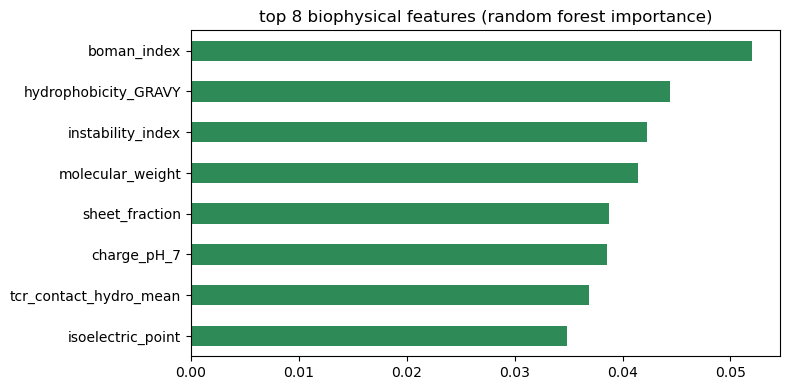

In [8]:
LEAKY_COLS = ["Disease", "strat_key", "found_in_healthy", "ID", "Tissue",
              "hla_population_freq", "Uniprot IDs", "source", "hla_source",
              "hla_known", "feature_error", "Affinity % Rank", "affinity_bin",
              "is_strong_binder", "is_weak_binder", "is_non_binder",
              "ms_confirmed", "MHC Class", "Peptide Modifications", "length_class"]
EXCLUDE = set(["is_cancer", "Peptide Sequence", "Best HLA Allele"]) | set(LEAKY_COLS)
BIO_CANDIDATES = [c for c in train_df.columns
                  if c not in EXCLUDE and pd.api.types.is_numeric_dtype(train_df[c])]

X_sel = (train_df[BIO_CANDIDATES].replace([np.inf, -np.inf], np.nan)
         .fillna(train_df[BIO_CANDIDATES].mean(numeric_only=True)).fillna(0))
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_sel, train_df["is_cancer"])
importance = pd.Series(rf.feature_importances_, index=BIO_CANDIDATES).sort_values(ascending=False)
TOP8 = importance.head(N_TOP_BIO).index.tolist()

print(f"top {N_TOP_BIO} biophysical features:")
for i, feat in enumerate(TOP8, 1):
    print(f"  {i}. {feat}  ({importance[feat]:.4f})")

bio_scaler = StandardScaler().fit(X_sel[TOP8].values)

plt.figure(figsize=(8, 4))
importance.head(N_TOP_BIO)[::-1].plot(kind="barh", color="seagreen")
plt.title(f"top {N_TOP_BIO} biophysical features (random forest importance)")
plt.tight_layout(); plt.show()

## 5. PyTorch Dataset + DataLoader




In [9]:
class PeptideMHCDataset(Dataset):
    def __init__(self, frame, scaler):
        self.pep = frame["Peptide Sequence"].tolist()
        self.allele = frame["Best HLA Allele"].tolist()
        self.labels = frame["is_cancer"].astype(int).values
        bio = (frame[TOP8].replace([np.inf, -np.inf], np.nan)
               .fillna(frame[TOP8].mean(numeric_only=True)).fillna(0).values)
        self.bio = scaler.transform(bio).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        pep_enc = encode_blosum(self.pep[i])
        length = min(pep_enc.shape[0], MAX_PEP_LEN)
        pep_pad = np.zeros((MAX_PEP_LEN, 20), dtype=np.float32)
        pep_pad[:length] = pep_enc[:length]
        pad_mask = np.ones(MAX_PEP_LEN, dtype=bool)
        pad_mask[:length] = False
        mhc_enc = encode_blosum(pseudo_map[self.allele[i]])
        return {
            "bio": torch.from_numpy(self.bio[i]),
            "pep": torch.from_numpy(pep_pad),
            "pep_mask": torch.from_numpy(pad_mask),
            "mhc": torch.from_numpy(mhc_enc),
            "label": torch.tensor(self.labels[i], dtype=torch.long),
        }

train_ds = PeptideMHCDataset(train_df, bio_scaler)
val_ds = PeptideMHCDataset(val_df, bio_scaler)
test_ds = PeptideMHCDataset(test_df, bio_scaler)

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

probe_batch = next(iter(train_loader))
print("batch shapes:")
for key, value in probe_batch.items():
    print(f"  {key:9s}: {tuple(value.shape)}  {value.dtype}")

batch shapes:
  bio      : (128, 8)  torch.float32
  pep      : (128, 25, 20)  torch.float32
  pep_mask : (128, 25)  torch.bool
  mhc      : (128, 165, 20)  torch.float32
  label    : (128,)  torch.int64


## 6. NEW OPTIM optimized model



In [10]:
class BetterThreeStageModel(nn.Module):
    def __init__(self, n_bio=N_TOP_BIO, d_model=96, n_heads=4, n_layers_pep=3,
                 n_layers_mhc=2, max_pep=MAX_PEP_LEN, in_dim=20, dropout=0.25):
        super().__init__()

        self.bio_mlp = nn.Sequential(
            nn.Linear(n_bio, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.pep_proj = nn.Linear(in_dim, d_model)
        self.pep_pos = nn.Embedding(max_pep, d_model)

        pep_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.pep_encoder = nn.TransformerEncoder(
            pep_layer, num_layers=n_layers_pep, enable_nested_tensor=False,
        )

        self.mhc_proj = nn.Linear(in_dim, d_model)
        self.mhc_pos = nn.Embedding(PSEUDO_LEN, d_model)

        mhc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.mhc_encoder = nn.TransformerEncoder(
            mhc_layer, num_layers=n_layers_mhc, enable_nested_tensor=False,
        )

        self.pep_to_mhc = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.mhc_to_pep = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.pep_cross_norm = nn.LayerNorm(d_model)
        self.mhc_cross_norm = nn.LayerNorm(d_model)

        self.fusion_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.fusion_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 5),
            nn.Linear(d_model * 5, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 2),
        )

    def masked_mean(self, x, pad_mask):
        keep = (~pad_mask).unsqueeze(-1).float()
        return (x * keep).sum(dim=1) / keep.sum(dim=1).clamp(min=1.0)

    def forward(self, bio, pep, pep_mask, mhc):
        B = bio.size(0)

        bio_tok = self.bio_mlp(bio)

        pep_pos = torch.arange(pep.size(1), device=pep.device).unsqueeze(0)
        pep_x = self.pep_proj(pep) + self.pep_pos(pep_pos)
        pep_x = self.pep_encoder(pep_x, src_key_padding_mask=pep_mask)
        pep_tok = self.masked_mean(pep_x, pep_mask)

        mhc_pos = torch.arange(mhc.size(1), device=mhc.device).unsqueeze(0)
        mhc_x = self.mhc_proj(mhc) + self.mhc_pos(mhc_pos)
        mhc_x = self.mhc_encoder(mhc_x)
        mhc_tok = mhc_x.mean(dim=1)

        pep_cross, _ = self.pep_to_mhc(query=pep_x, key=mhc_x, value=mhc_x)
        pep_cross = self.pep_cross_norm(pep_x + pep_cross)
        pep_mhc_tok = self.masked_mean(pep_cross, pep_mask)

        mhc_cross, _ = self.mhc_to_pep(query=mhc_x, key=pep_x, value=pep_x, key_padding_mask=pep_mask)
        mhc_cross = self.mhc_cross_norm(mhc_x + mhc_cross)
        mhc_pep_tok = mhc_cross.mean(dim=1)

        tokens = torch.stack([bio_tok, pep_tok, mhc_tok, pep_mhc_tok, mhc_pep_tok], dim=1)
        fused, _ = self.fusion_attn(tokens, tokens, tokens)
        fused = self.fusion_norm(tokens + fused)

        logits = self.classifier(fused.reshape(B, -1))
        return logits

## 7. NEW OPTIM training system

The `CFG` dictionary and the whole training toolkit: seeding, model/loss/optimizer/scheduler builders, an AMP-aware
epoch loop, `train_model` with early stopping and best-checkpoint saving, plus evaluation, threshold search and history
plots. `score_metric` is `val_bal_acc` here because class II is close to balanced but we care about both classes.


In [11]:
CFG = {
    "d_model": 96,
    "n_heads": 4,
    "n_layers_pep": 3,
    "n_layers_mhc": 2,
    "in_dim": 20,
    "dropout": 0.25,
    "lr": 7e-4,
    "weight_decay": 1e-3,
    "epochs": 40,
    "patience": 8,
    "grad_clip": 1.0,
    "label_smoothing": 0.03,
    "use_class_weights": False,
    "score_metric": "val_bal_acc",
    "checkpoint_name": "better_threestage_classII_best.pt",
}


def seed_everything(seed=RANDOM_STATE):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def to_device(batch):
    return (
        batch["bio"].to(device),
        batch["pep"].to(device),
        batch["pep_mask"].to(device),
        batch["mhc"].to(device),
        batch["label"].to(device),
    )


def get_class_weights(frame):
    counts = np.bincount(frame["is_cancer"].astype(int).values)
    weights = counts.sum() / (2.0 * counts)
    return torch.tensor(weights, dtype=torch.float32).to(device)


def build_model(cfg):
    model = BetterThreeStageModel(
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        n_layers_pep=cfg["n_layers_pep"],
        n_layers_mhc=cfg["n_layers_mhc"],
        in_dim=cfg["in_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    return model


def build_loss(cfg):
    weights = get_class_weights(train_df) if cfg["use_class_weights"] else None
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=cfg["label_smoothing"])


def build_optimizer(model, cfg):
    return torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])


def build_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


def dry_run_model(model, loss_fn):
    model.train()
    batch = next(iter(train_loader))
    bio, pep, pep_mask, mhc, label = to_device(batch)
    logits = model(bio, pep, pep_mask, mhc)
    assert logits.shape == (bio.size(0), 2), f"bad output shape {logits.shape}"
    assert not torch.isnan(logits).any(), "NaNs in logits"
    loss = loss_fn(logits, label)
    loss.backward()
    grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
    print("dry run passed")
    print("output shape:", tuple(logits.shape))
    print("loss:", round(loss.item(), 4))
    print("grad norm:", round(grad_norm, 4))
    model.zero_grad()


def run_epoch(model, loader, loss_fn, optimizer=None, scaler=None, cfg=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_true, all_pred, all_prob = [], [], []
    use_amp = device.type == "cuda"
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            bio, pep, pep_mask, mhc, label = to_device(batch)
            amp_context = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
            with amp_context:
                logits = model(bio, pep, pep_mask, mhc)
                loss = loss_fn(logits, label)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                    optimizer.step()
            total_loss += loss.item() * label.size(0)
            prob = torch.softmax(logits.detach(), dim=1)[:, 1]
            pred = logits.detach().argmax(dim=1)
            all_true.extend(label.cpu().tolist())
            all_pred.extend(pred.cpu().tolist())
            all_prob.extend(prob.cpu().tolist())
    avg_loss = total_loss / len(all_true)
    acc = accuracy_score(all_true, all_pred)
    bal_acc = balanced_accuracy_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except ValueError:
        auc = 0.0
    return {"loss": avg_loss, "acc": acc, "bal_acc": bal_acc, "auc": auc,
            "true": all_true, "pred": all_pred, "prob": all_prob}


def get_score(metrics, metric_name):
    return {"val_acc": metrics["acc"], "val_bal_acc": metrics["bal_acc"], "val_auc": metrics["auc"]}[metric_name]


def train_model(cfg):
    seed_everything()
    model = build_model(cfg)
    loss_fn = build_loss(cfg)
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    ckpt_path = os.path.join(CACHE_DIR, cfg["checkpoint_name"])

    print(model)
    print("trainable params:", count_params(model))
    dry_run_model(model, loss_fn)

    best_score, best_state, wait = -1, None, 0
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
            "train_bal_acc": [], "val_bal_acc": [], "train_auc": [], "val_auc": []}

    for epoch in range(1, cfg["epochs"] + 1):
        train_metrics = run_epoch(model, train_loader, loss_fn, optimizer=optimizer, scaler=scaler, cfg=cfg)
        val_metrics = run_epoch(model, val_loader, loss_fn, cfg=cfg)

        for key, tag in [("loss", "loss"), ("acc", "acc"), ("bal_acc", "bal_acc"), ("auc", "auc")]:
            hist["train_" + tag].append(train_metrics[key])
            hist["val_" + tag].append(val_metrics[key])

        score = get_score(val_metrics, cfg["score_metric"])
        scheduler.step(score)

        print(f"epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} acc {train_metrics['acc']:.4f} "
              f"bal {train_metrics['bal_acc']:.4f} auc {train_metrics['auc']:.4f} | "
              f"val loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} "
              f"bal {val_metrics['bal_acc']:.4f} auc {val_metrics['auc']:.4f}")

        if score > best_score:
            best_score, best_state, wait = score, copy.deepcopy(model.state_dict()), 0
            torch.save(best_state, ckpt_path)
        else:
            wait += 1
            if wait >= cfg["patience"]:
                print(f"early stopping at epoch {epoch}")
                break

    print(f"\nbest {cfg['score_metric']}: {best_score:.4f}")
    print(f"saved to: {ckpt_path}")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, hist, ckpt_path


def collect_outputs(model, loader):
    model.eval()
    all_true, all_prob = [], []
    with torch.no_grad():
        for batch in loader:
            bio, pep, pep_mask, mhc, label = to_device(batch)
            logits = model(bio, pep, pep_mask, mhc)
            prob = torch.softmax(logits, dim=1)[:, 1]
            all_true.extend(label.cpu().tolist())
            all_prob.extend(prob.cpu().tolist())
    return np.array(all_true), np.array(all_prob)


def find_best_threshold(y_true, y_prob, metric="balanced_accuracy"):
    best_t, best_score = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        score = balanced_accuracy_score(y_true, pred) if metric == "balanced_accuracy" else accuracy_score(y_true, pred)
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score


def evaluate_model(model, loader, threshold=0.5, title="TEST SET"):
    y_true, y_prob = collect_outputs(model, loader)
    y_pred = (y_prob >= threshold).astype(int)
    print(f"===== {title} =====")
    print(f"threshold:         {threshold:.3f}")
    print(f"accuracy:          {accuracy_score(y_true, y_pred):.4f}")
    print(f"balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"roc auc:           {roc_auc_score(y_true, y_prob):.4f}")
    print("\nclassification report:")
    print(classification_report(y_true, y_pred, target_names=["healthy", "cancer"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["healthy", "cancer"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["healthy", "cancer"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    plt.tight_layout(); plt.show()
    return {"true": y_true, "prob": y_prob, "pred": y_pred}


def plot_history(hist):
    plt.figure(figsize=(7, 4))
    plt.plot(hist["train_acc"], label="train acc")
    plt.plot(hist["val_acc"], label="val acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("accuracy curve"); plt.legend()
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["train_auc"], label="train auc")
    plt.plot(hist["val_auc"], label="val auc")
    plt.xlabel("epoch"); plt.ylabel("roc auc"); plt.title("auc curve"); plt.legend()
    plt.tight_layout(); plt.show()

## 8. Dry run


In [12]:
seed_everything()
probe_model = build_model(CFG)
print("trainable params:", count_params(probe_model))
dry_run_model(probe_model, build_loss(CFG))

trainable params: 816386
dry run passed
output shape: (128, 2)
loss: 0.6911
grad norm: 1.6433


## 9. Train 


/var/folders/vs/1x2cctjj76q80zjkdspl6hd80000gn/T/ipykernel_93990/3386092084.py:141: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


BetterThreeStageModel(
  (bio_mlp): Sequential(
    (0): Linear(in_features=8, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=96, out_features=96, bias=True)
    (5): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
  )
  (pep_proj): Linear(in_features=20, out_features=96, bias=True)
  (pep_pos): Embedding(25, 96)
  (pep_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,),

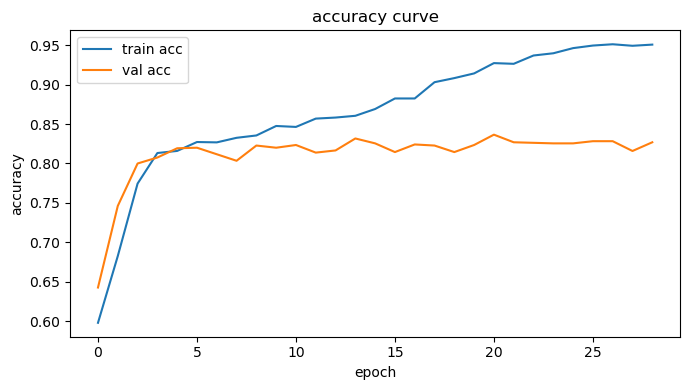

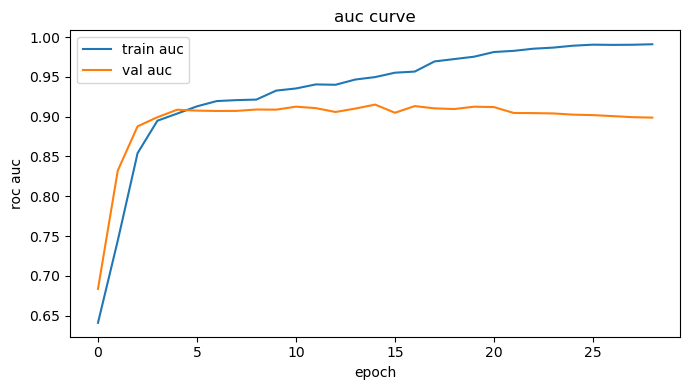

best validation threshold: 0.485  balanced acc: 0.8368
===== TEST SET DEFAULT THRESHOLD =====
threshold:         0.500
accuracy:          0.8264
balanced accuracy: 0.8265
roc auc:           0.9081

classification report:
              precision    recall  f1-score   support

     healthy     0.8447    0.8017    0.8226       726
      cancer     0.8098    0.8514    0.8301       720

    accuracy                         0.8264      1446
   macro avg     0.8272    0.8265    0.8263      1446
weighted avg     0.8273    0.8264    0.8263      1446



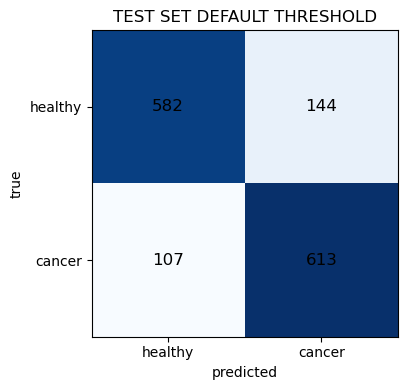

===== TEST SET TUNED THRESHOLD =====
threshold:         0.485
accuracy:          0.8250
balanced accuracy: 0.8252
roc auc:           0.9081

classification report:
              precision    recall  f1-score   support

     healthy     0.8463    0.7961    0.8204       726
      cancer     0.8060    0.8542    0.8294       720

    accuracy                         0.8250      1446
   macro avg     0.8261    0.8252    0.8249      1446
weighted avg     0.8262    0.8250    0.8249      1446



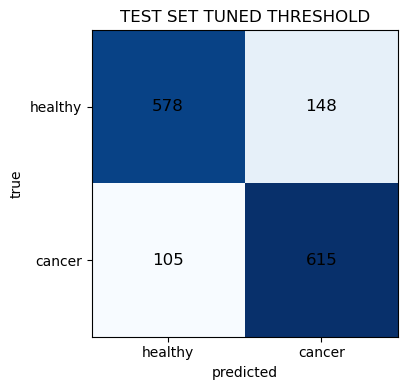

{'true': array([0, 1, 1, ..., 1, 1, 0], shape=(1446,)),
 'prob': array([0.01137915, 0.97254193, 0.98804188, ..., 0.85050076, 0.16558881,
        0.03241463], shape=(1446,)),
 'pred': array([0, 1, 1, ..., 1, 0, 0], shape=(1446,))}

In [13]:
model, hist, ckpt_path = train_model(CFG)
plot_history(hist)

val_true, val_prob = collect_outputs(model, val_loader)
best_threshold, best_val = find_best_threshold(val_true, val_prob, metric="balanced_accuracy")
print("best validation threshold:", round(best_threshold, 3), " balanced acc:", round(best_val, 4))

evaluate_model(model, test_loader, threshold=0.5, title="TEST SET DEFAULT THRESHOLD")
evaluate_model(model, test_loader, threshold=best_threshold, title="TEST SET TUNED THRESHOLD")